In [2]:


import os
import joblib
import numpy as np

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF,
    ConstantKernel,
    WhiteKernel
)

# ============================================================
# SETTINGS
# ============================================================

PCA_DIR = "Ppca_outputs"
OUTDIR  = "pGP_outputs"

FIELD = "TT"

# ============================================================
# CREATE OUTPUT DIR
# ============================================================

os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(f"{OUTDIR}/{FIELD}", exist_ok=True)

# ============================================================
# HELPERS
# ============================================================

def read_info(fname):

    info = {}

    with open(fname, "r") as f:

        for line in f:

            parts = line.strip().split()

            if len(parts) != 2:
                continue

            k, v = parts

            try:
                info[k] = int(v)

            except:
                info[k] = float(v)

    return info


def load_array(fname, shape=None, dtype=np.float64):

    arr = np.fromfile(fname, dtype=dtype)

    if shape is not None:

        shape = list(shape)

        if -1 in shape:

            idx = shape.index(-1)

            known = 1

            for s in shape:

                if s != -1:
                    known *= s

            shape[idx] = arr.size // known

        arr = arr.reshape(shape)

    return arr


def save_array(fname, arr):

    arr.astype(np.float64).tofile(fname)


# ============================================================
# LOAD PCA INFO
# ============================================================

info = read_info(
    f"{PCA_DIR}/{FIELD}_info.txt"
)

Ntrain = info["Ntrain"]
Ntest  = info["Ntest"]
nmodes = info["modes"]

print("\n================================================")
print("SKLEARN GP TRAINING")
print("================================================")

print("Field  :", FIELD)
print("Ntrain :", Ntrain)
print("Ntest  :", Ntest)
print("Modes  :", nmodes)

# ============================================================
# LOAD PARAMETERS
# ============================================================

params = load_array(
    f"{PCA_DIR}/params_4999.bin",
    (-1, 11)
)

train_idx = np.fromfile(
    "fisher_data_all4/train_idx.bin",
    dtype=np.int64
)

test_idx = np.fromfile(
    "fisher_data_all4/test_idx.bin",
    dtype=np.int64
)

X_train = params[train_idx]
X_test  = params[test_idx]

print("\nParameter shapes:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

# ============================================================
# LOAD PCA COEFFS
# ============================================================

Y_train = load_array(
    f"{PCA_DIR}/{FIELD}_coeff_train.bin",
    (Ntrain, nmodes)
)

Y_test = load_array(
    f"{PCA_DIR}/{FIELD}_coeff_test.bin",
    (Ntest, nmodes)
)

print("\nCoefficient shapes:")
print("Y_train:", Y_train.shape)
print("Y_test :", Y_test.shape)

# ============================================================
# NORMALIZE INPUTS
# ============================================================

X_mean = X_train.mean(axis=0)
X_std  = X_train.std(axis=0)

X_std[X_std == 0] = 1.0

X_train_norm = (
    X_train - X_mean
) / X_std

X_test_norm = (
    X_test - X_mean
) / X_std

save_array(
    f"{OUTDIR}/{FIELD}/X_mean.bin",
    X_mean
)

save_array(
    f"{OUTDIR}/{FIELD}/X_std.bin",
    X_std
)

# ============================================================
# STORAGE
# ============================================================

pred_mean_all = np.zeros(
    (Ntest, nmodes)
)

pred_std_all = np.zeros(
    (Ntest, nmodes)
)

# ============================================================
# GP LOOP
# ============================================================

for mode in range(nmodes):

    print("\n------------------------------------------------")
    print(f"MODE {mode}")
    print("------------------------------------------------")

    # --------------------------------------------------------
    # TARGETS
    # --------------------------------------------------------

    y_train = Y_train[:, mode]
    y_test  = Y_test[:, mode]

    # --------------------------------------------------------
    # NORMALIZE TARGETS
    # --------------------------------------------------------

    y_mean = y_train.mean()
    y_std  = y_train.std()

    if y_std == 0:
        y_std = 1.0

    y_train_norm = (
        y_train - y_mean
    ) / y_std

    save_array(
        f"{OUTDIR}/{FIELD}/ymean_mode_{mode}.bin",
        np.array([y_mean])
    )

    save_array(
        f"{OUTDIR}/{FIELD}/ystd_mode_{mode}.bin",
        np.array([y_std])
    )

    # --------------------------------------------------------
    # KERNEL
    # --------------------------------------------------------

    kernel = (
        ConstantKernel(
            1.0,
            (1e-3, 1e3)
        )
        *
        RBF(
            length_scale=np.ones(
                X_train.shape[1]
            ),
            length_scale_bounds=(
                1e-3,
                1e3
            )
        )
        +
        WhiteKernel(
            noise_level=1e-5,
            noise_level_bounds=(
                1e-10,
                1e1
            )
        )
    )

    # --------------------------------------------------------
    # GP MODEL
    # --------------------------------------------------------

    gp = GaussianProcessRegressor(

        kernel=kernel,

        alpha=0.0,

        normalize_y=False,

        n_restarts_optimizer=10,

        random_state=42
    )

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    print("\nTraining GP...")

    gp.fit(
        X_train_norm,
        y_train_norm
    )

    print("\nOptimized kernel:")
    print(gp.kernel_)

    # --------------------------------------------------------
    # SAVE MODEL
    # --------------------------------------------------------

    joblib.dump(
        gp,
        f"{OUTDIR}/{FIELD}/gp_mode_{mode}.joblib"
    )

    # --------------------------------------------------------
    # PREDICT
    # --------------------------------------------------------

    pred_mean_norm, pred_std_norm = gp.predict(
        X_test_norm,
        return_std=True
    )

    # --------------------------------------------------------
    # UNNORMALIZE
    # --------------------------------------------------------

    pred_mean = (
        pred_mean_norm * y_std
        +
        y_mean
    )

    pred_std = (
        pred_std_norm * y_std
    )

    pred_mean_all[:, mode] = pred_mean
    pred_std_all[:, mode]  = pred_std

    # --------------------------------------------------------
    # ERRORS
    # --------------------------------------------------------

    mae = np.mean(
        np.abs(pred_mean - y_test)
    )

    rmse = np.sqrt(
        np.mean(
            (pred_mean - y_test)**2
        )
    )

    maxerr = np.max(
        np.abs(pred_mean - y_test)
    )

    print("\nErrors:")

    print(f"MAE     = {mae:.6e}")
    print(f"RMSE    = {rmse:.6e}")
    print(f"MAX ERR = {maxerr:.6e}")

# ============================================================
# SAVE PREDICTIONS
# ============================================================

save_array(
    f"{OUTDIR}/{FIELD}/pred_coeff_mean.bin",
    pred_mean_all
)

save_array(
    f"{OUTDIR}/{FIELD}/pred_coeff_std.bin",
    pred_std_all
)

save_array(
    f"{OUTDIR}/{FIELD}/true_coeff_test.bin",
    Y_test
)

# ============================================================
# SAVE INFO
# ============================================================

with open(
    f"{OUTDIR}/{FIELD}/gp_info.txt",
    "w"
) as f:

    f.write(f"FIELD {FIELD}\n")
    f.write(f"Ntrain {Ntrain}\n")
    f.write(f"Ntest {Ntest}\n")
    f.write(f"nmodes {nmodes}\n")

# ============================================================
# DONE
# ============================================================

print("\n================================================")
print("DONE")
print("================================================")

print("\nSaved in:")
print(f"{OUTDIR}/{FIELD}/")


SKLEARN GP TRAINING
Field  : TT
Ntrain : 200
Ntest  : 10
Modes  : 7

Parameter shapes:
X_train: (200, 11)
X_test : (10, 11)

Coefficient shapes:
Y_train: (200, 7)
Y_test : (10, 7)

------------------------------------------------
MODE 0
------------------------------------------------

Training GP...


/home/apps/DL/DL-CondaPy3.7/lib/python3.7/site-packages/sklearn/gaussian_process/kernels.py:437: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  ConvergenceWarning,
/home/apps/DL/DL-CondaPy3.7/lib/python3.7/site-packages/sklearn/gaussian_process/kernels.py:437: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  ConvergenceWarning,
/home/apps/DL/DL-CondaPy3.7/lib/python3.7/site-packages/sklearn/gaussian_process/kernels.py:437: ConvergenceWarning: The optimal value found for dimension 7 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  ConvergenceWarning,
/home/apps/DL/DL-Co


Optimized kernel:
3.66**2 * RBF(length_scale=[1e+03, 1e+03, 11.8, 32, 17.6, 18.4, 10.1, 1e+03, 1e+03, 28.3, 0.662]) + WhiteKernel(noise_level=0.00508)

Errors:
MAE     = 3.042854e-03
RMSE    = 4.567037e-03
MAX ERR = 1.135053e-02

------------------------------------------------
MODE 1
------------------------------------------------

Training GP...


/home/apps/DL/DL-CondaPy3.7/lib/python3.7/site-packages/sklearn/gaussian_process/kernels.py:437: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  ConvergenceWarning,
/home/apps/DL/DL-CondaPy3.7/lib/python3.7/site-packages/sklearn/gaussian_process/kernels.py:437: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  ConvergenceWarning,
/home/apps/DL/DL-CondaPy3.7/lib/python3.7/site-packages/sklearn/gaussian_process/kernels.py:437: ConvergenceWarning: The optimal value found for dimension 5 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  ConvergenceWarning,
/home/apps/DL/DL-Co


Optimized kernel:
1.03**2 * RBF(length_scale=[15.1, 1.25, 1e+03, 1e+03, 8.67, 1e+03, 1.23, 3.53, 1e+03, 3.45, 0.206]) + WhiteKernel(noise_level=0.0341)

Errors:
MAE     = 1.140761e-02
RMSE    = 1.776356e-02
MAX ERR = 5.009838e-02

------------------------------------------------
MODE 2
------------------------------------------------

Training GP...


...


Optimized kernel:
31.6**2 * RBF(length_scale=[1e+03, 19.1, 39.3, 18, 45.6, 15.9, 37.1, 1e+03, 31.5, 19.2, 7.36]) + WhiteKernel(noise_level=0.0303)

Errors:
MAE     = 8.202246e-04
RMSE    = 9.163126e-04
MAX ERR = 1.609749e-03

------------------------------------------------
MODE 5
------------------------------------------------

Training GP...


/home/apps/DL/DL-CondaPy3.7/lib/python3.7/site-packages/sklearn/gaussian_process/kernels.py:437: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  ConvergenceWarning,
/home/apps/DL/DL-CondaPy3.7/lib/python3.7/site-packages/sklearn/gaussian_process/kernels.py:437: ConvergenceWarning: The optimal value found for dimension 5 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  ConvergenceWarning,



Optimized kernel:
31.6**2 * RBF(length_scale=[54.8, 63.6, 7.65, 92.4, 35.6, 1e+03, 21.9, 8.86, 23.7, 11, 8.1]) + WhiteKernel(noise_level=0.0308)

Errors:
MAE     = 5.787291e-04
RMSE    = 7.301953e-04
MAX ERR = 1.365803e-03

------------------------------------------------
MODE 6
------------------------------------------------

Training GP...


/home/apps/DL/DL-CondaPy3.7/lib/python3.7/site-packages/sklearn/gaussian_process/kernels.py:437: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  ConvergenceWarning,
/home/apps/DL/DL-CondaPy3.7/lib/python3.7/site-packages/sklearn/gaussian_process/kernels.py:437: ConvergenceWarning: The optimal value found for dimension 5 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  ConvergenceWarning,



Optimized kernel:
1.03**2 * RBF(length_scale=[0.971, 461, 1e+03, 0.805, 0.762, 1e+03, 1.46, 1.26, 254, 0.592, 0.874]) + WhiteKernel(noise_level=1e-05)

Errors:
MAE     = 2.785704e-03
RMSE    = 3.218250e-03
MAX ERR = 5.516434e-03

DONE

Saved in:
pGP_outputs/TT/



LOADING GP RESULTS
Field : TT
Ntest : 10
Modes : 7

------------------------------------------------
MODE 0
------------------------------------------------
MAE     = 1.352588e-02
RMSE    = 1.986220e-02
MAX ERR = 4.749907e-02

------------------------------------------------
MODE 1
------------------------------------------------
MAE     = 9.109264e-03
RMSE    = 1.136373e-02
MAX ERR = 2.532770e-02

------------------------------------------------
MODE 2
------------------------------------------------
MAE     = 3.070431e-03
RMSE    = 3.690860e-03
MAX ERR = 7.244376e-03

------------------------------------------------
MODE 3
------------------------------------------------
MAE     = 4.402855e-03
RMSE    = 5.890519e-03
MAX ERR = 1.374042e-02

------------------------------------------------
MODE 4
------------------------------------------------
MAE     = 1.954207e-03
RMSE    = 2.453973e-03
MAX ERR = 4.420897e-03

------------------------------------------------
MODE 5
----------------

/home/shambhavij.sps.iitmandi/.local/lib/python3.7/site-packages/ipykernel_launcher.py:249: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).


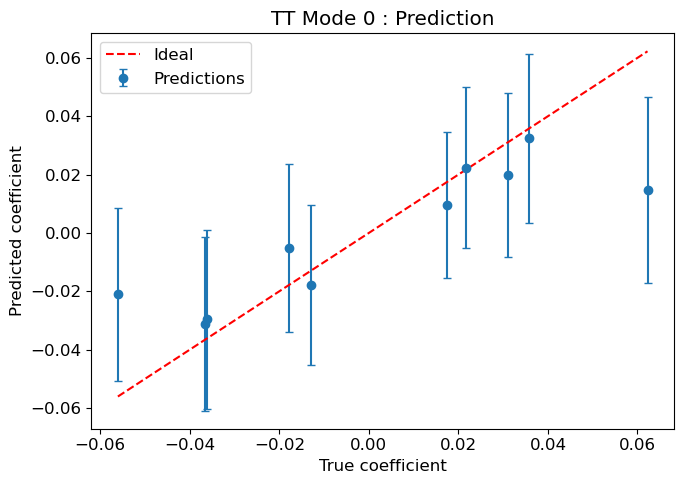

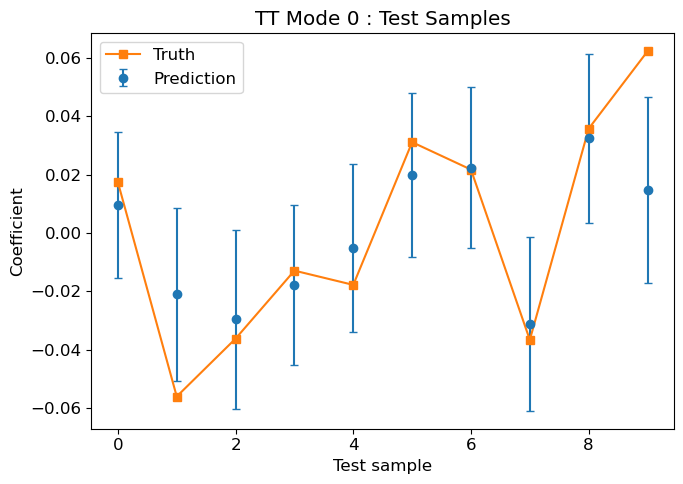

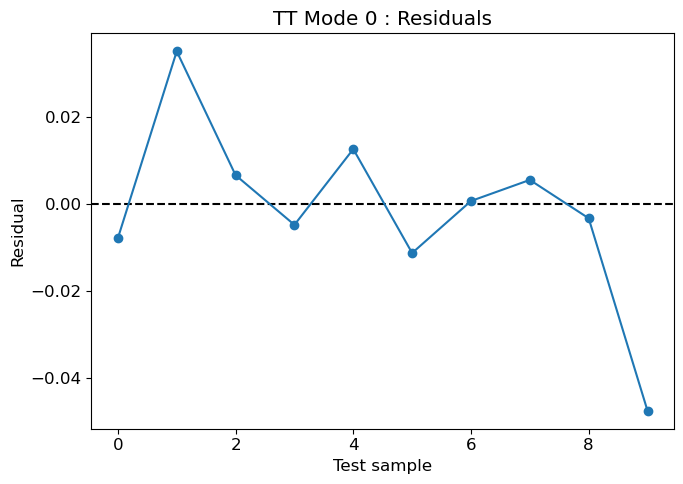

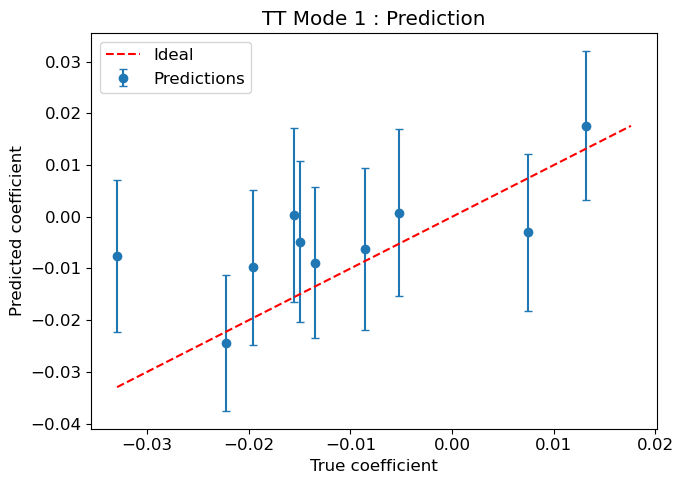

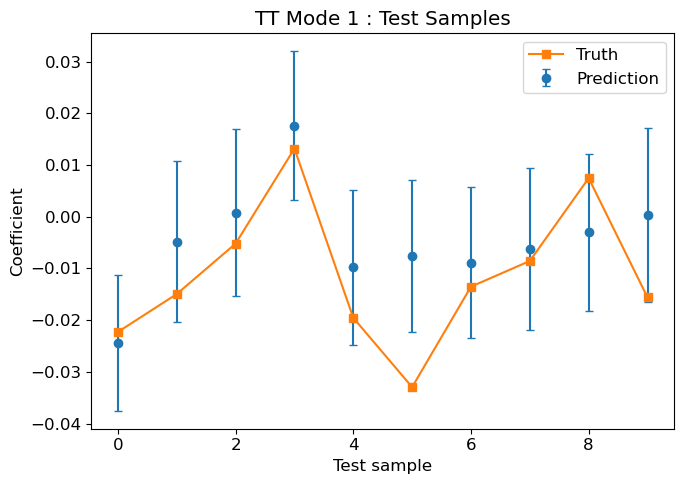

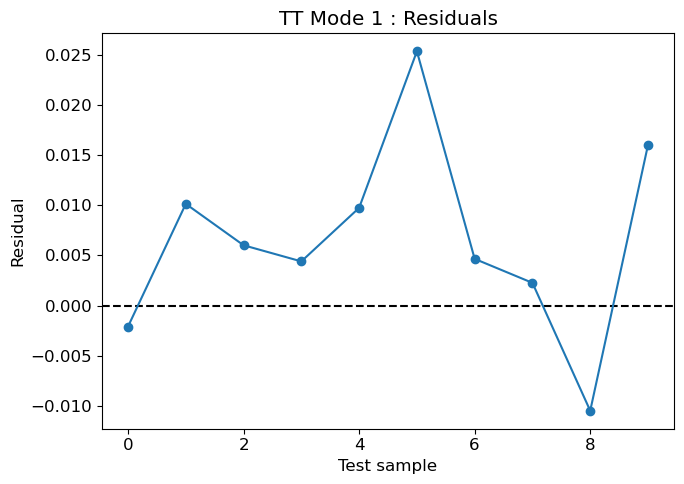

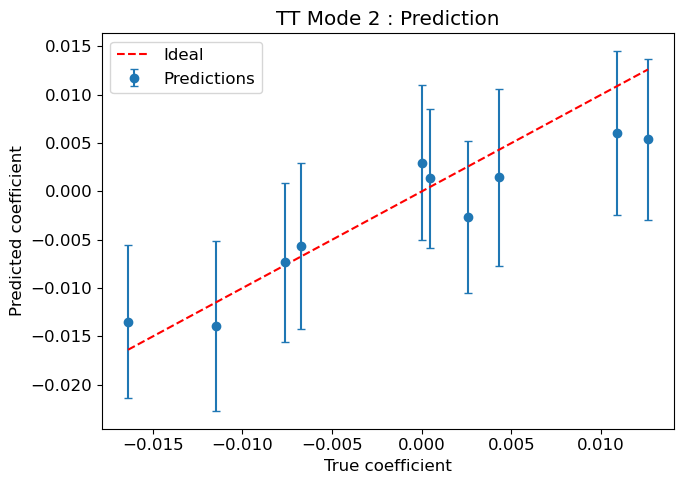

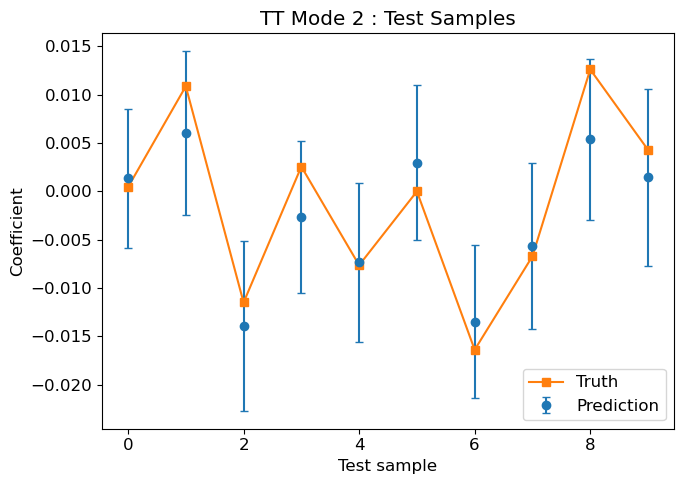

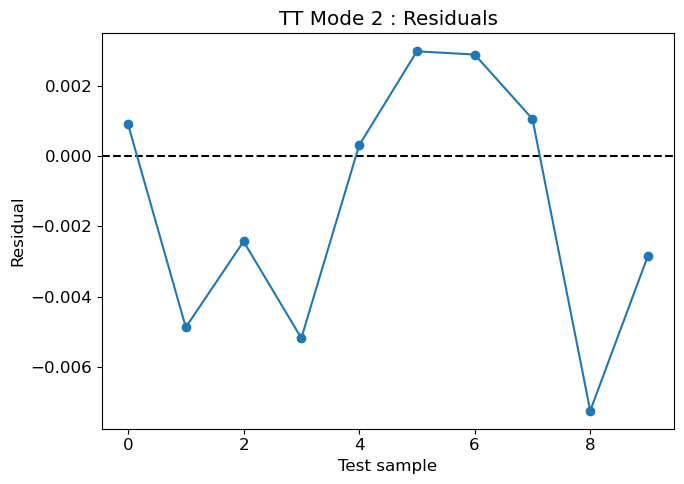

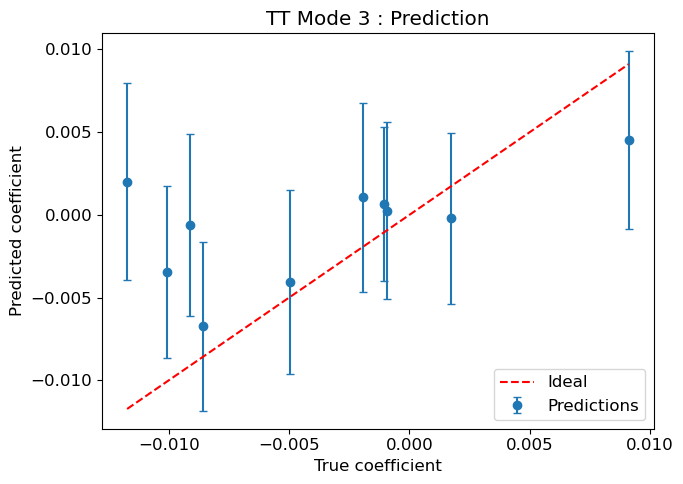

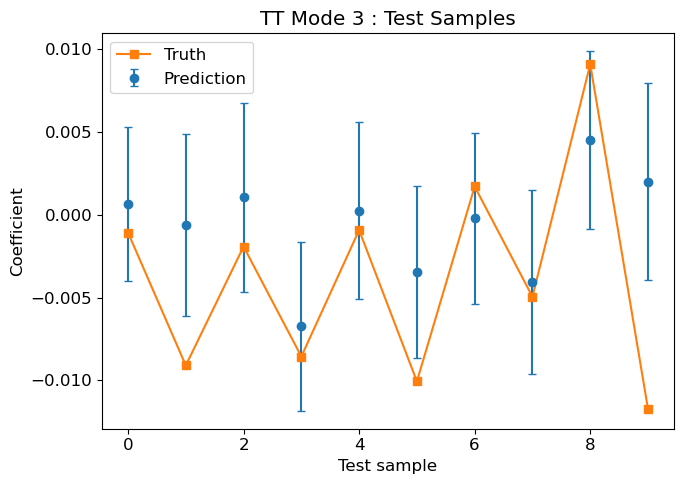

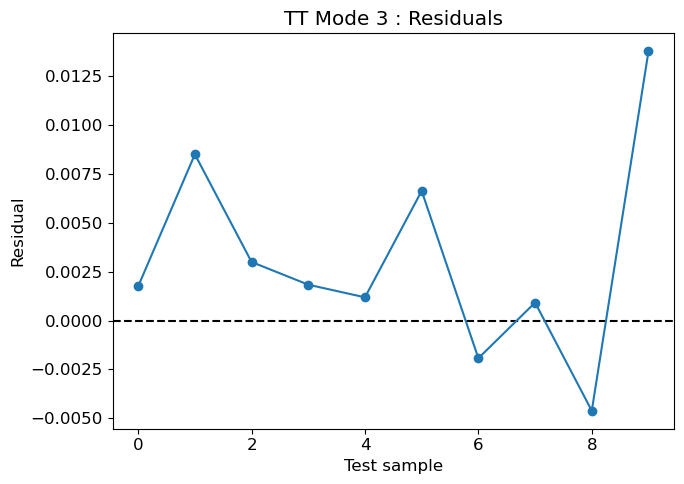

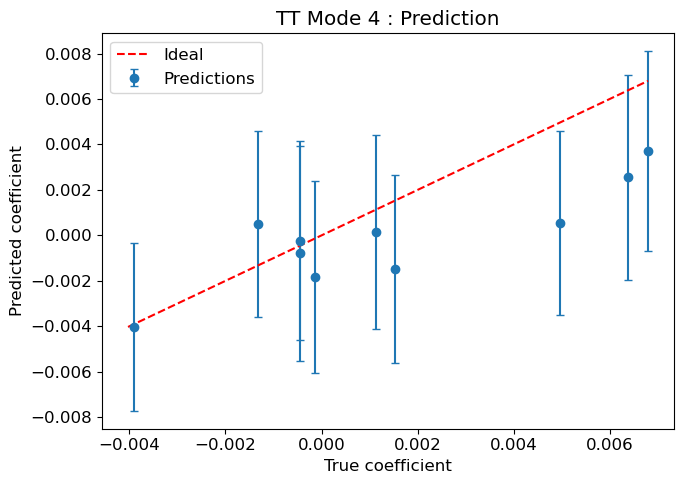

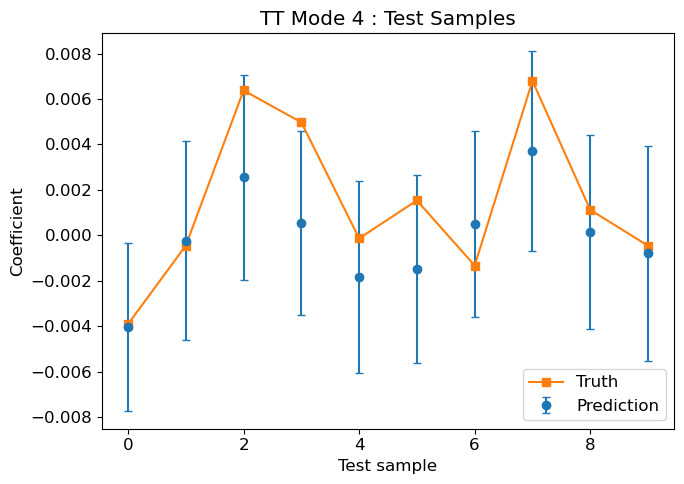

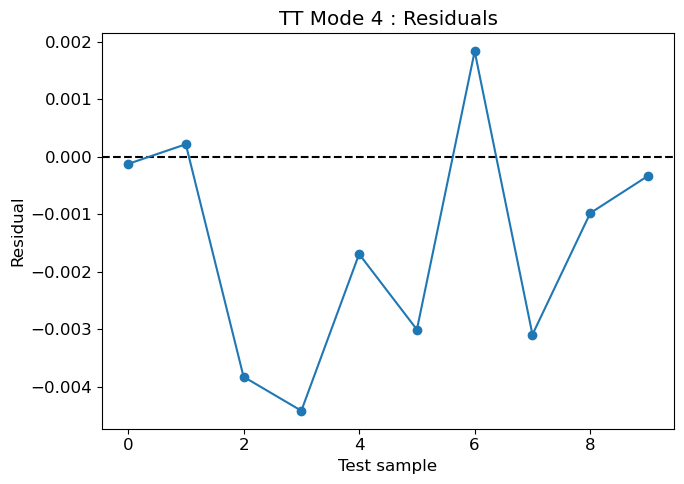

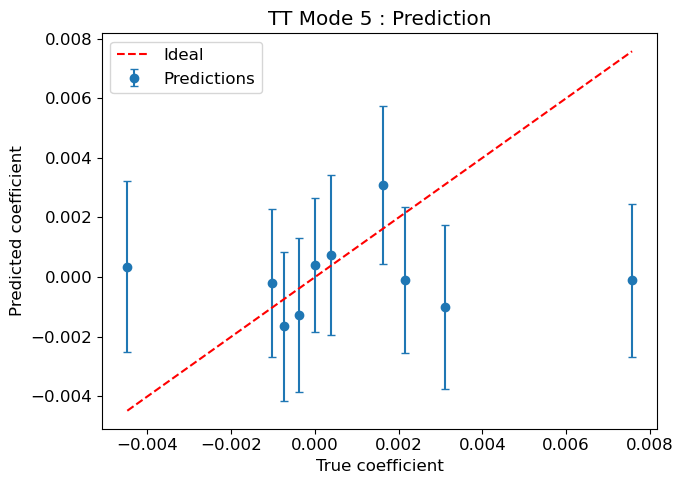

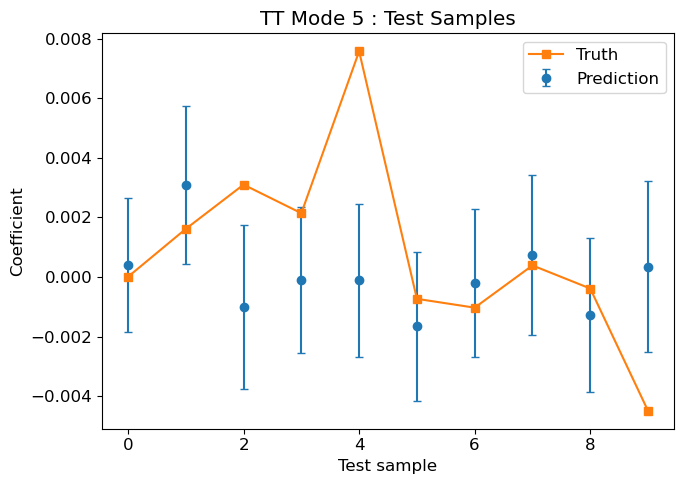

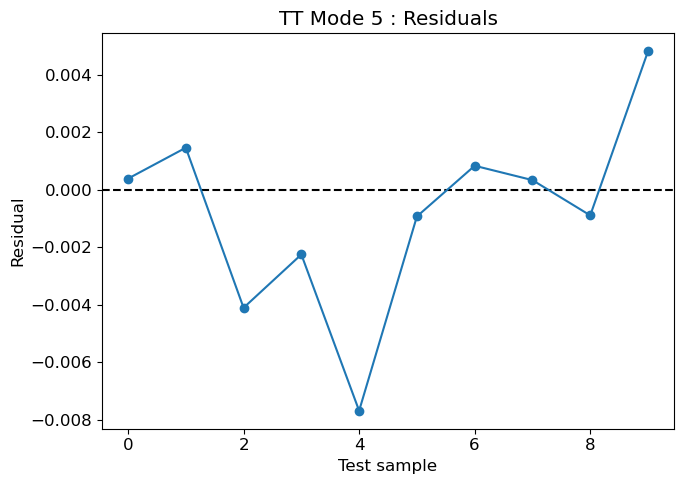

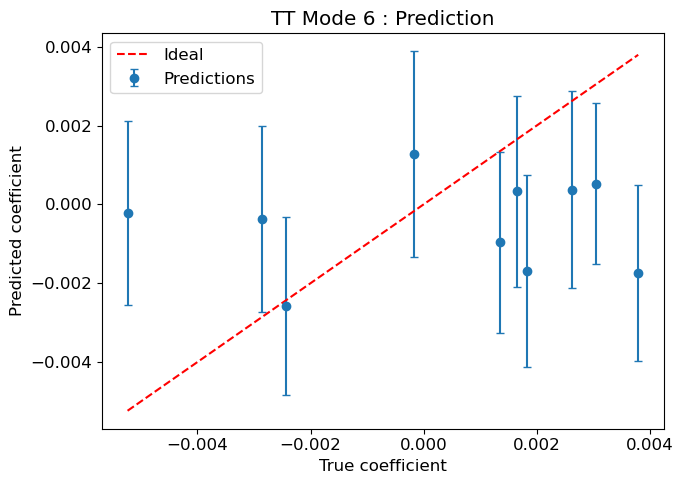

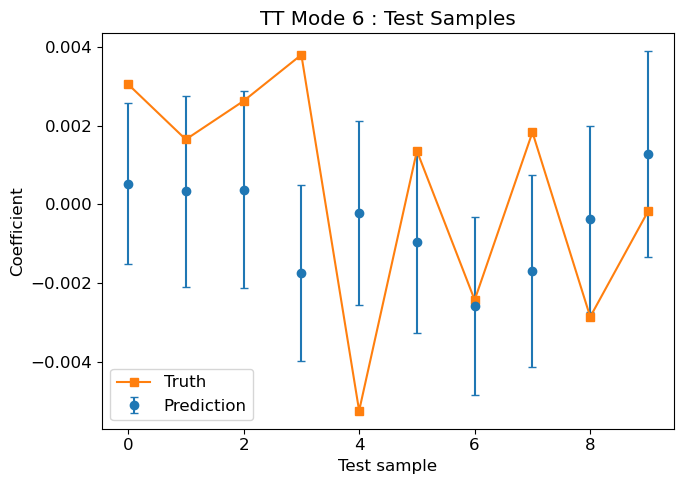

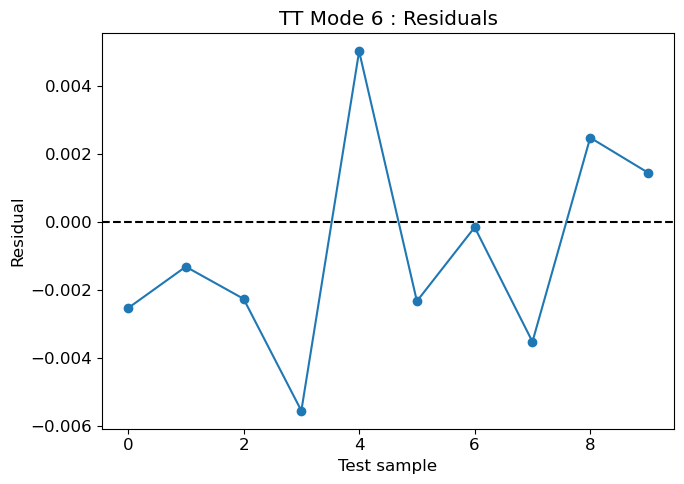

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# SETTINGS
# ============================================================

GP_DIR = "cGP_outputs"
FIELD = "TT"

# ============================================================
# HELPERS
# ============================================================

def read_info(fname):

    info = {}

    with open(fname, "r") as f:

        for line in f:

            parts = line.strip().split()

            if len(parts) != 2:
                continue

            k, v = parts

            # try int
            try:

                info[k] = int(v)
                continue

            except ValueError:
                pass

            # try float
            try:

                info[k] = float(v)
                continue

            except ValueError:
                pass

            # fallback string
            info[k] = v

    return info


def load_array(fname, shape=None):

    arr = np.fromfile(
        fname,
        dtype=np.float64
    )

    if shape is not None:

        shape = list(shape)

        if -1 in shape:

            idx = shape.index(-1)

            known = 1

            for s in shape:

                if s != -1:
                    known *= s

            shape[idx] = arr.size // known

        arr = arr.reshape(shape)

    return arr

# ============================================================
# LOAD INFO
# ============================================================

info = read_info(
    f"{GP_DIR}/{FIELD}/gp_info.txt"
)

Ntest  = info["Ntest"]
nmodes = info["nmodes"]

print("\n================================================")
print("LOADING GP RESULTS")
print("================================================")

print("Field :", FIELD)
print("Ntest :", Ntest)
print("Modes :", nmodes)

# ============================================================
# LOAD DATA
# ============================================================

pred_mean = load_array(
    f"{GP_DIR}/{FIELD}/pred_coeff_mean.bin",
    (Ntest, nmodes)
)

pred_std = load_array(
    f"{GP_DIR}/{FIELD}/pred_coeff_std.bin",
    (Ntest, nmodes)
)

true_coeff = load_array(
    f"{GP_DIR}/{FIELD}/true_coeff_test.bin",
    (Ntest, nmodes)
)

# ============================================================
# GLOBAL STYLE
# ============================================================

plt.rcParams["figure.figsize"] = (7,5)
plt.rcParams["font.size"] = 12

# ============================================================
# MODE-BY-MODE PLOTS
# ============================================================

for mode in range(nmodes):

    print("\n------------------------------------------------")
    print(f"MODE {mode}")
    print("------------------------------------------------")

    y_true = true_coeff[:, mode]

    y_pred = pred_mean[:, mode]

    y_std = pred_std[:, mode]

    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    mae = np.mean(
        np.abs(y_true - y_pred)
    )

    rmse = np.sqrt(
        np.mean(
            (y_true - y_pred)**2
        )
    )

    maxerr = np.max(
        np.abs(y_true - y_pred)
    )

    print(f"MAE     = {mae:.6e}")
    print(f"RMSE    = {rmse:.6e}")
    print(f"MAX ERR = {maxerr:.6e}")

    # ========================================================
    # SCATTER : TRUE VS PREDICTED
    # ========================================================

    plt.figure()

    plt.errorbar(
        y_true,
        y_pred,
        yerr=y_std,
        fmt='o',
        capsize=3,
        label='Predictions'
    )

    xmin = min(
        y_true.min(),
        y_pred.min()
    )

    xmax = max(
        y_true.max(),
        y_pred.max()
    )

    plt.plot(
        [xmin, xmax],
        [xmin, xmax],
        'r--',
        label='Ideal'
    )

    plt.xlabel("True coefficient")
    plt.ylabel("Predicted coefficient")

    plt.title(
        f"{FIELD} Mode {mode} : Prediction"
    )

    plt.legend()

    plt.tight_layout()

    # ========================================================
    # TEST SAMPLE INDEX PLOT
    # ========================================================

    plt.figure()

    idx = np.arange(Ntest)

    plt.errorbar(
        idx,
        y_pred,
        yerr=y_std,
        fmt='o',
        capsize=3,
        label='Prediction'
    )

    plt.plot(
        idx,
        y_true,
        's-',
        label='Truth'
    )

    plt.xlabel("Test sample")
    plt.ylabel("Coefficient")

    plt.title(
        f"{FIELD} Mode {mode} : Test Samples"
    )

    plt.legend()

    plt.tight_layout()

    # ========================================================
    # RESIDUALS
    # ========================================================

    residual = y_pred - y_true

    plt.figure()

    plt.axhline(
        0.0,
        color='k',
        linestyle='--'
    )

    plt.plot(
        idx,
        residual,
        'o-'
    )

    plt.xlabel("Test sample")
    plt.ylabel("Residual")

    plt.title(
        f"{FIELD} Mode {mode} : Residuals"
    )

    plt.tight_layout()

# ============================================================
# SHOW ALL
# ============================================================

plt.show()